# FIX vs GO Neural Decoder - Phase 2: Decoder Training

This notebook implements Phase 2 of the Xie-style decoder following the plan in `FIX_GO_DECODER_PLAN.md`.

**Goal**: Train and evaluate two decoder architectures:
1. **Logistic Regression** (simple, interpretable)
2. **Xie Decoder** (2D hidden layer for visualization)

**Reference**: Xie et al. (2022) "Geometry of sequence working memory in macaque prefrontal cortex" - Figure 3A

## Phase 2 Checklist

- [ ] Load prepared data from Phase 1
- [ ] Implement Logistic Regression decoder
- [ ] Implement Xie-style decoder (PyTorch)
- [ ] Train both decoders (per direction)
- [ ] Evaluate on test set
- [ ] Visualize results (ROC curves, confusion matrices)
- [ ] Save trained models

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import sys

# Scikit-learn for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, 
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# PyTorch for Xie Decoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Imports loaded successfully!
PyTorch version: 2.9.1+cu130
CUDA available: True


## 2. Load Prepared Data from Phase 1

In [2]:
# Configuration
session_id = 'fi211025a'
ssd_num = 2

# Load prepared data
data_dir = Path.cwd().parents[1] / 'data' / 'decoder_data'
data_file = data_dir / f'decoder_data_{session_id}_ssd{ssd_num}.pkl'

print(f"Loading data from: {data_file}")

with open(data_file, 'rb') as f:
    prepared_data = pickle.load(f)

# Extract configuration
session_id = prepared_data['session_id']
ssd_number = prepared_data['ssd_number']
rt_multiplier = prepared_data['rt_multiplier']
test_size = prepared_data['test_size']
random_state = prepared_data['random_state']
epoch_defs = prepared_data['epoch_defs']
normalized_datasets = prepared_data['datasets']

# Direction mapping
dir_map = {0: 'Right', 180: 'Left'}
directions = [0, 180]

print(f"\n✓ Data loaded successfully!")
print(f"  Session: {session_id}")
print(f"  SSD level: {ssd_number}")
print(f"  RT multiplier: {rt_multiplier}")
print(f"  Test size: {test_size * 100}%")
print(f"  Random state: {random_state}")

# Display dataset info
for direction in directions:
    dataset = normalized_datasets[direction]
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print(f"  Training samples: {len(dataset['X_train'])}")
    print(f"  Test samples: {len(dataset['X_test'])}")
    print(f"  Number of neurons: {len(dataset['cell_ids'])}")
    print(f"  mean_ssd2: {dataset['mean_ssd']:.2f} ms")

Loading data from: /home/barak/Projects/population-analysis/data/decoder_data/decoder_data_fi211025a_ssd2.pkl

✓ Data loaded successfully!
  Session: fi211025a
  SSD level: 2
  RT multiplier: 1.3
  Test size: 20.0%
  Random state: 42

Right Direction (0°):
  Training samples: 696
  Test samples: 174
  Number of neurons: 150
  mean_ssd2: 108.00 ms

Left Direction (180°):
  Training samples: 718
  Test samples: 180
  Number of neurons: 150
  mean_ssd2: 108.00 ms


## 3. Logistic Regression Decoder

Simple binary classifier with L2 regularization.

### 3.1 Train Logistic Regression with Hyperparameter Tuning

In [3]:
def train_logistic_regression(X_train, y_train, cv=5):
    """
    Train logistic regression with cross-validation for C parameter.
    
    Parameters:
    -----------
    X_train : ndarray
        Training features
    y_train : ndarray
        Training labels
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    best_model : LogisticRegression
        Best model from grid search
    grid_search : GridSearchCV
        Grid search object with results
    """
    # Define parameter grid
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    }
    
    # Base model
    base_model = LogisticRegression(
        # penalty='l1',
        l1_ratio=0, 
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=random_state
    )
    
    # Grid search with cross-validation
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    print("Training Logistic Regression with grid search...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n✓ Training complete!")
    print(f"  Best C: {grid_search.best_params_['C']}")
    print(f"  Best CV score (balanced accuracy): {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_, grid_search


# Train for each direction
lr_models = {}

print("=" * 80)
print("TRAINING LOGISTIC REGRESSION DECODERS")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print("-" * 60)
    
    dataset = normalized_datasets[direction]
    X_train = dataset['X_train']
    y_train = dataset['y_train']
    
    model, grid_search = train_logistic_regression(X_train, y_train)
    
    lr_models[direction] = {
        'model': model,
        'grid_search': grid_search
    }

print("\n" + "=" * 80)
print("✓ All Logistic Regression models trained")
print("=" * 80)

TRAINING LOGISTIC REGRESSION DECODERS

Right Direction (0°):
------------------------------------------------------------
Training Logistic Regression with grid search...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✓ Training complete!
  Best C: 0.01
  Best CV score (balanced accuracy): 0.8678

Left Direction (180°):
------------------------------------------------------------
Training Logistic Regression with grid search...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✓ Training complete!
  Best C: 0.01
  Best CV score (balanced accuracy): 0.8427

✓ All Logistic Regression models trained


In [4]:
lr_models[0]['model'].coef_

array([[-6.15189978e-02, -2.63154190e-02,  3.95457807e-02,
         8.95207468e-03, -1.25851512e-01, -6.11210718e-02,
        -2.78780964e-02,  1.24719473e-01,  9.62153050e-02,
         1.94836230e-01,  3.72951738e-02, -3.17682821e-02,
        -7.41501818e-02,  4.86933848e-03,  3.86114274e-02,
         2.92245821e-02, -6.51596894e-02, -2.18107473e-04,
         5.74921648e-02,  6.05907448e-02, -4.41184396e-04,
        -1.49832486e-01, -1.09173666e-02, -1.49629112e-01,
        -4.15603954e-02,  1.86004912e-01, -3.43324051e-02,
        -6.08297252e-02, -3.47612189e-02,  1.86663839e-02,
         4.87200543e-02,  1.58960028e-01, -1.18014572e-02,
         3.59493166e-02,  7.05287047e-02, -4.95093089e-02,
         3.58699769e-01, -1.68887670e-03,  1.63032744e-01,
         4.07129194e-02,  5.75178629e-02,  2.69067627e-02,
         1.15277074e-01, -8.85687316e-03, -4.03268339e-02,
        -3.24345454e-02, -1.13587942e-02,  3.06847984e-01,
         4.64252405e-02, -2.68244655e-03, -4.05843406e-0

### 3.2 Evaluate Logistic Regression

In [5]:
def evaluate_classifier(model, X_test, y_test, model_name="Classifier"):
    """
    Evaluate classifier and return metrics.
    
    Parameters:
    -----------
    model : classifier
        Trained classifier with predict and predict_proba methods
    X_test : ndarray
        Test features
    y_test : ndarray
        Test labels
    model_name : str
        Name for display
    
    Returns:
    --------
    results : dict
        Dictionary with predictions and metrics
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (GO)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Display results
    print(f"\n{model_name} Test Performance:")
    print("-" * 60)
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  {conf_matrix}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['FIX', 'GO']))
    
    return {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'auc_roc': auc_roc,
        'confusion_matrix': conf_matrix
    }


# Evaluate for each direction
lr_results = {}

print("=" * 80)
print("LOGISTIC REGRESSION EVALUATION")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    
    dataset = normalized_datasets[direction]
    model = lr_models[direction]['model']
    
    results = evaluate_classifier(
        model,
        dataset['X_test'],
        dataset['y_test'],
        model_name="Logistic Regression"
    )
    
    lr_results[direction] = results

LOGISTIC REGRESSION EVALUATION

Right Direction (0°):

Logistic Regression Test Performance:
------------------------------------------------------------
  Accuracy: 0.8908
  Balanced Accuracy: 0.8908
  AUC-ROC: 0.9597

  Confusion Matrix:
  [[79  8]
 [11 76]]

  Classification Report:
              precision    recall  f1-score   support

         FIX       0.88      0.91      0.89        87
          GO       0.90      0.87      0.89        87

    accuracy                           0.89       174
   macro avg       0.89      0.89      0.89       174
weighted avg       0.89      0.89      0.89       174


Left Direction (180°):

Logistic Regression Test Performance:
------------------------------------------------------------
  Accuracy: 0.8222
  Balanced Accuracy: 0.8222
  AUC-ROC: 0.9204

  Confusion Matrix:
  [[73 17]
 [15 75]]

  Classification Report:
              precision    recall  f1-score   support

         FIX       0.83      0.81      0.82        90
          GO       0

## 4. Xie-Style Decoder (PyTorch)

Linear decoder with 2D hidden layer for visualization.

### 4.1 Define Xie Decoder Architecture

In [6]:
class XieDecoder(nn.Module):
    """
    Xie-style decoder with 2D hidden layer.
    
    Architecture:
    - Linear projection from n_neurons to 2D hidden space (W)
    - Linear projection from 2D to n_classes (M)
    
    Following Xie et al. (2022) Figure 3A.
    """
    def __init__(self, n_neurons, hidden_dim=2, n_classes=2):
        super().__init__()
        self.n_neurons = n_neurons
        self.hidden_dim = hidden_dim
        self.n_classes = n_classes
        
        # Linear projection to hidden state
        self.W = nn.Linear(n_neurons, hidden_dim, bias=True)
        
        # Target vectors (projection to class logits)
        self.M = nn.Linear(hidden_dim, n_classes, bias=False)
    
    def forward(self, x):
        """
        Forward pass.
        
        Parameters:
        -----------
        x : torch.Tensor (batch_size, n_neurons)
            Input neural activity
        
        Returns:
        --------
        logits : torch.Tensor (batch_size, n_classes)
            Class logits
        h : torch.Tensor (batch_size, hidden_dim)
            Hidden state (2D representation)
        """
        h = self.W(x)  # Project to 2D hidden space
        logits = self.M(h)  # Compare with target vectors
        return logits, h
    
    def predict_proba(self, x):
        """
        Predict class probabilities (for compatibility with sklearn metrics).
        """
        with torch.no_grad():
            logits, _ = self.forward(x)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()
    
    def predict(self, x):
        """
        Predict class labels (for compatibility with sklearn metrics).
        """
        probs = self.predict_proba(x)
        return np.argmax(probs, axis=1)


print("✓ XieDecoder architecture defined")

✓ XieDecoder architecture defined


### 4.2 Training Function for Xie Decoder

In [7]:
def train_xie_decoder(X_train, y_train, X_test=None, y_test=None,
                     hidden_dim=2, n_epochs=500, batch_size=64,
                     lr=1e-3, weight_decay=0.01, verbose=True):
    """
    Train Xie decoder.
    
    Parameters:
    -----------
    X_train : ndarray
        Training features
    y_train : ndarray
        Training labels
    X_test : ndarray, optional
        Test features (for monitoring)
    y_test : ndarray, optional
        Test labels (for monitoring)
    hidden_dim : int
        Hidden layer dimensionality (default 2)
    n_epochs : int
        Number of training epochs
    batch_size : int
        Batch size
    lr : float
        Learning rate
    weight_decay : float
        L2 regularization strength
    verbose : bool
        Print training progress
    
    Returns:
    --------
    model : XieDecoder
        Trained model
    history : dict
        Training history
    """
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.LongTensor(y_train).to(device)
    
    if X_test is not None:
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        y_test_tensor = torch.LongTensor(y_test).to(device)
    
    # Create data loader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    n_neurons = X_train.shape[1]
    model = XieDecoder(n_neurons, hidden_dim=hidden_dim).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    # Training loop
    if verbose:
        print(f"Training Xie Decoder on {device}...")
        print(f"  Hidden dim: {hidden_dim}")
        print(f"  Epochs: {n_epochs}")
        print(f"  Batch size: {batch_size}")
        print(f"  Learning rate: {lr}")
        print(f"  Weight decay: {weight_decay}")
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits, h = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(X_batch)
            pred = torch.argmax(logits, dim=1)
            train_correct += (pred == y_batch).sum().item()
            train_total += len(X_batch)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Evaluation on test set
        if X_test is not None:
            model.eval()
            with torch.no_grad():
                logits_test, _ = model(X_test_tensor)
                test_loss = criterion(logits_test, y_test_tensor).item()
                pred_test = torch.argmax(logits_test, dim=1)
                test_acc = (pred_test == y_test_tensor).float().mean().item()
            
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)
        
        # Print progress
        if verbose and (epoch + 1) % 50 == 0:
            if X_test is not None:
                print(f"  Epoch {epoch+1}/{n_epochs}: "
                      f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
                      f"Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")
            else:
                print(f"  Epoch {epoch+1}/{n_epochs}: "
                      f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")
    
    if verbose:
        print(f"\n✓ Training complete!")
        print(f"  Final train accuracy: {train_acc:.4f}")
        if X_test is not None:
            print(f"  Final test accuracy: {test_acc:.4f}")
    
    return model, history


print("✓ Training function defined")

✓ Training function defined


### 4.3 Train Xie Decoders

In [8]:
# Training hyperparameters
HIDDEN_DIM = 2
N_EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.01

# Train for each direction
xie_models = {}

print("=" * 80)
print("TRAINING XIE DECODERS")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    print("-" * 60)
    
    dataset = normalized_datasets[direction]
    
    model, history = train_xie_decoder(
        dataset['X_train'],
        dataset['y_train'],
        dataset['X_test'],
        dataset['y_test'],
        hidden_dim=HIDDEN_DIM,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        verbose=True
    )
    
    xie_models[direction] = {
        'model': model,
        'history': history
    }

print("\n" + "=" * 80)
print("✓ All Xie models trained")
print("=" * 80)

TRAINING XIE DECODERS

Right Direction (0°):
------------------------------------------------------------
Training Xie Decoder on cuda...
  Hidden dim: 2
  Epochs: 500
  Batch size: 64
  Learning rate: 0.001
  Weight decay: 0.01
  Epoch 50/500: Train Loss=0.1718, Train Acc=0.9483, Test Loss=0.2710, Test Acc=0.8851
  Epoch 100/500: Train Loss=0.1365, Train Acc=0.9598, Test Loss=0.2940, Test Acc=0.8793
  Epoch 150/500: Train Loss=0.1271, Train Acc=0.9641, Test Loss=0.3151, Test Acc=0.8793
  Epoch 200/500: Train Loss=0.1230, Train Acc=0.9655, Test Loss=0.3328, Test Acc=0.8851
  Epoch 250/500: Train Loss=0.1211, Train Acc=0.9655, Test Loss=0.3396, Test Acc=0.8851
  Epoch 300/500: Train Loss=0.1204, Train Acc=0.9655, Test Loss=0.3419, Test Acc=0.8851
  Epoch 350/500: Train Loss=0.1201, Train Acc=0.9655, Test Loss=0.3447, Test Acc=0.8851
  Epoch 400/500: Train Loss=0.1202, Train Acc=0.9655, Test Loss=0.3435, Test Acc=0.8851
  Epoch 450/500: Train Loss=0.1199, Train Acc=0.9655, Test Loss=0.34

### 4.4 Evaluate Xie Decoders

In [9]:
# Evaluate for each direction
xie_results = {}

print("=" * 80)
print("XIE DECODER EVALUATION")
print("=" * 80)

for direction in directions:
    print(f"\n{dir_map[direction]} Direction ({direction}°):")
    
    dataset = normalized_datasets[direction]
    model = xie_models[direction]['model']
    
    # Convert test data to tensor
    device = next(model.parameters()).device
    X_test_tensor = torch.FloatTensor(dataset['X_test']).to(device)
    
    results = evaluate_classifier(
        model,
        X_test_tensor,
        dataset['y_test'],
        model_name="Xie Decoder"
    )
    
    xie_results[direction] = results

XIE DECODER EVALUATION

Right Direction (0°):

Xie Decoder Test Performance:
------------------------------------------------------------
  Accuracy: 0.8851
  Balanced Accuracy: 0.8851
  AUC-ROC: 0.9507

  Confusion Matrix:
  [[78  9]
 [11 76]]

  Classification Report:
              precision    recall  f1-score   support

         FIX       0.88      0.90      0.89        87
          GO       0.89      0.87      0.88        87

    accuracy                           0.89       174
   macro avg       0.89      0.89      0.89       174
weighted avg       0.89      0.89      0.89       174


Left Direction (180°):

Xie Decoder Test Performance:
------------------------------------------------------------
  Accuracy: 0.7889
  Balanced Accuracy: 0.7889
  AUC-ROC: 0.8969

  Confusion Matrix:
  [[72 18]
 [20 70]]

  Classification Report:
              precision    recall  f1-score   support

         FIX       0.78      0.80      0.79        90
          GO       0.80      0.78      0.79 

## 5. Visualization

Compare performance of both decoders.

### 5.1 Learning Curves (Xie Decoder)

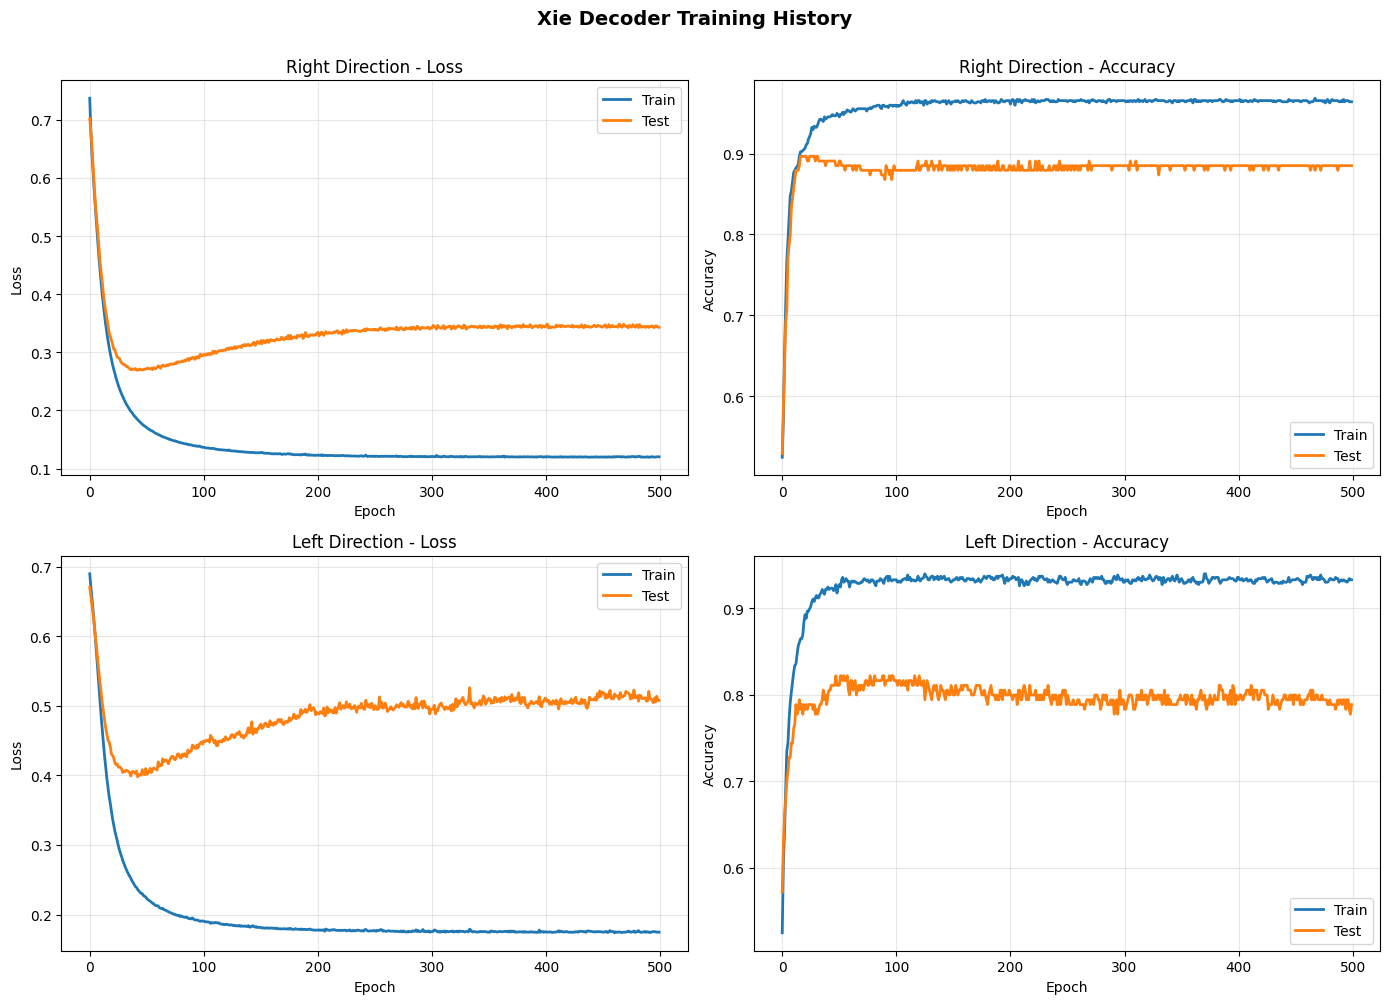

In [10]:
# Plot learning curves for Xie decoders
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, direction in enumerate(directions):
    history = xie_models[direction]['history']
    
    # Loss
    ax = axes[idx, 0]
    ax.plot(history['train_loss'], label='Train', linewidth=2)
    ax.plot(history['test_loss'], label='Test', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{dir_map[direction]} Direction - Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Accuracy
    ax = axes[idx, 1]
    ax.plot(history['train_acc'], label='Train', linewidth=2)
    ax.plot(history['test_acc'], label='Test', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{dir_map[direction]} Direction - Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Xie Decoder Training History', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### 5.2 ROC Curves

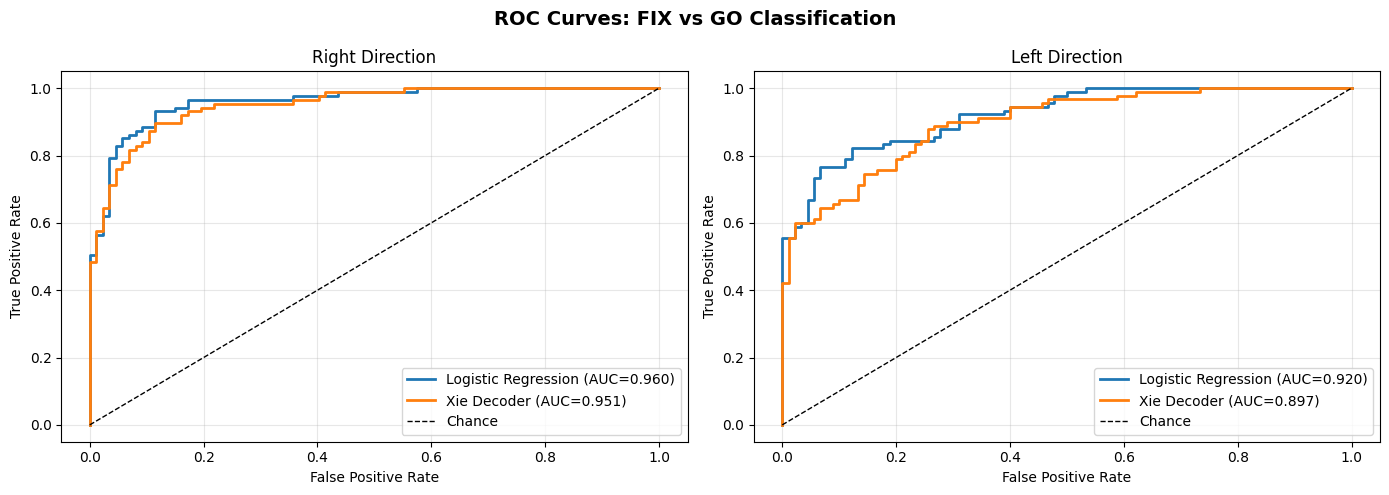

In [11]:
# Plot ROC curves for both decoders
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, direction in enumerate(directions):
    ax = axes[idx]
    
    dataset = normalized_datasets[direction]
    y_test = dataset['y_test']
    
    # Logistic Regression ROC
    lr_prob = lr_results[direction]['y_prob']
    lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
    lr_auc = lr_results[direction]['auc_roc']
    
    # Xie Decoder ROC
    xie_prob = xie_results[direction]['y_prob']
    xie_fpr, xie_tpr, _ = roc_curve(y_test, xie_prob)
    xie_auc = xie_results[direction]['auc_roc']
    
    # Plot
    ax.plot(lr_fpr, lr_tpr, linewidth=2, label=f'Logistic Regression (AUC={lr_auc:.3f})')
    ax.plot(xie_fpr, xie_tpr, linewidth=2, label=f'Xie Decoder (AUC={xie_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{dir_map[direction]} Direction')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: FIX vs GO Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrices

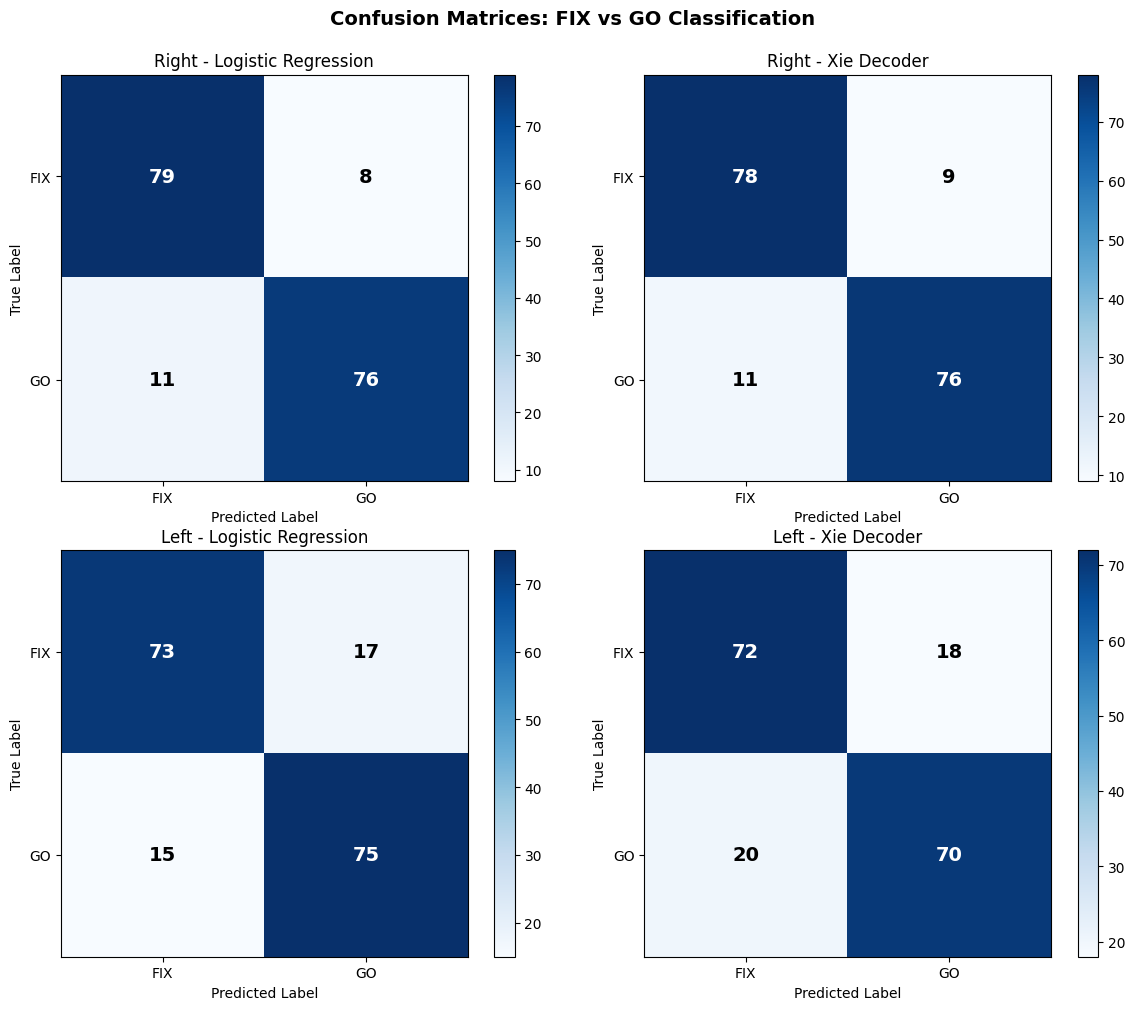

In [12]:
def plot_confusion_matrix(cm, title, ax):
    """
    Plot confusion matrix.
    """
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    
    # Labels
    classes = ['FIX', 'GO']
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')
    
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.colorbar(im, ax=ax)


# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, direction in enumerate(directions):
    # Logistic Regression
    cm_lr = lr_results[direction]['confusion_matrix']
    plot_confusion_matrix(cm_lr, 
                         f'{dir_map[direction]} - Logistic Regression',
                         axes[idx, 0])
    
    # Xie Decoder
    cm_xie = xie_results[direction]['confusion_matrix']
    plot_confusion_matrix(cm_xie,
                         f'{dir_map[direction]} - Xie Decoder',
                         axes[idx, 1])

plt.suptitle('Confusion Matrices: FIX vs GO Classification', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### 5.4 Performance Summary Table

In [13]:
# Create summary table
summary_data = []

for direction in directions:
    # Logistic Regression
    summary_data.append({
        'Direction': dir_map[direction],
        'Model': 'Logistic Regression',
        'Accuracy': f"{lr_results[direction]['accuracy']:.4f}",
        'Balanced Accuracy': f"{lr_results[direction]['balanced_accuracy']:.4f}",
        'AUC-ROC': f"{lr_results[direction]['auc_roc']:.4f}"
    })
    
    # Xie Decoder
    summary_data.append({
        'Direction': dir_map[direction],
        'Model': 'Xie Decoder',
        'Accuracy': f"{xie_results[direction]['accuracy']:.4f}",
        'Balanced Accuracy': f"{xie_results[direction]['balanced_accuracy']:.4f}",
        'AUC-ROC': f"{xie_results[direction]['auc_roc']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)


PERFORMANCE SUMMARY
Direction               Model Accuracy Balanced Accuracy AUC-ROC
    Right Logistic Regression   0.8908            0.8908  0.9597
    Right         Xie Decoder   0.8851            0.8851  0.9507
     Left Logistic Regression   0.8222            0.8222  0.9204
     Left         Xie Decoder   0.7889            0.7889  0.8969


## 6. Save Trained Models

In [14]:
import joblib

# Create output directory
models_dir = Path.cwd().parents[1] / 'data' / 'decoder_models'
models_dir.mkdir(exist_ok=True, parents=True)

print("Saving trained models...")
print("=" * 80)

for direction in directions:
    dir_name = dir_map[direction].lower()
    
    # Save Logistic Regression
    lr_file = models_dir / f'lr_decoder_{session_id}_ssd{ssd_num}_{dir_name}.joblib'
    joblib.dump(lr_models[direction], lr_file)
    print(f"✓ Saved Logistic Regression ({dir_map[direction]}): {lr_file.name}")
    
    # Save Xie Decoder
    xie_file = models_dir / f'xie_decoder_{session_id}_ssd{ssd_num}_{dir_name}.pt'
    torch.save({
        'model_state_dict': xie_models[direction]['model'].state_dict(),
        'history': xie_models[direction]['history'],
        'n_neurons': xie_models[direction]['model'].n_neurons,
        'hidden_dim': xie_models[direction]['model'].hidden_dim,
        'hyperparameters': {
            'n_epochs': N_EPOCHS,
            'batch_size': BATCH_SIZE,
            'lr': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY
        }
    }, xie_file)
    print(f"✓ Saved Xie Decoder ({dir_map[direction]}): {xie_file.name}")

# Save results summary
results_file = models_dir / f'results_summary_{session_id}_ssd{ssd_num}.pkl'
with open(results_file, 'wb') as f:
    pickle.dump({
        'lr_results': lr_results,
        'xie_results': xie_results,
        'summary_df': summary_df
    }, f)
print(f"✓ Saved results summary: {results_file.name}")

print("=" * 80)
print(f"\n✓ All models saved to: {models_dir}")

Saving trained models...
✓ Saved Logistic Regression (Right): lr_decoder_fi211025a_ssd2_right.joblib
✓ Saved Xie Decoder (Right): xie_decoder_fi211025a_ssd2_right.pt
✓ Saved Logistic Regression (Left): lr_decoder_fi211025a_ssd2_left.joblib
✓ Saved Xie Decoder (Left): xie_decoder_fi211025a_ssd2_left.pt
✓ Saved results summary: results_summary_fi211025a_ssd2.pkl

✓ All models saved to: /home/barak/Projects/population-analysis/data/decoder_models


---

## Phase 2 Checklist - COMPLETE ✓

- [x] Load prepared data from Phase 1
- [x] Implement Logistic Regression decoder
- [x] Implement Xie-style decoder (PyTorch)
- [x] Train both decoders (per direction)
- [x] Evaluate on test set
- [x] Visualize results (ROC curves, confusion matrices, learning curves)
- [x] Save trained models

**Next Steps**: Phase 3 - Visualization & Interpretation (neural state space, weight analysis)